In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# --- Models ---
# =========================================================
def S21_complex(f, f0, k, amp, phi):
    """Asymmetric complex S21 model (no delay)"""
    val = amp * np.exp(1j*phi) / (1 + 1j*2*(f - f0)/k)
    return np.concatenate([val.real, val.imag])

def S21_complex_delay(f, f0, k, amp, phi, tau):
    """Asymmetric complex S21 model with cable delay"""
    delay_phase = np.exp(-1j * 2 * np.pi * f * tau)
    val = amp * np.exp(1j*phi) / (1 + 1j*2*(f - f0)/k)
    val = val * delay_phase
    return np.concatenate([val.real, val.imag])

# =========================================================
# --- Initial guess ---
# =========================================================
def initial_guess(f, s21):
    mag = np.abs(s21)
    amp = np.max(mag)
    f0 = f[np.argmax(mag)]
    half_max = amp / 2
    indices = np.where(mag >= half_max)[0]
    k = f[indices[-1]] - f[indices[0]] if len(indices) >= 2 else (f[-1]-f[0])/10
    phi = 0.0
    return [f0, k, amp, phi]

def initial_guess_delay(f, s21):
    p0 = initial_guess(f, s21)
    tau = 1e-9   # 1 ns starting guess
    return p0 + [tau]

# =========================================================
# --- Polar fit functions ---
# =========================================================
def fit_and_plot_polar(file_path, f_start, f_end):
    """No delay model (for narrowband data)"""
    # Read CSV
    df = pd.read_csv(file_path)
    mag = df['Magnitude_abs'].values
    phase_deg = df['Phase_deg'].values
    phase_rad = np.deg2rad(phase_deg)

    # Frequency array
    f = np.linspace(f_start, f_end, len(mag))

    # Complex data
    s21 = mag * np.exp(1j*phase_rad)

    # Initial guess
    p0 = initial_guess(f, s21)

    # Fit
    ydata = np.concatenate([s21.real, s21.imag])
    popt, pcov = curve_fit(S21_complex, f, ydata, p0=p0)

    # Dense fit
    f_dense = np.linspace(f[0], f[-1], 2000)
    s21_fit_dense = popt[2]*np.exp(1j*popt[3]) / (1 + 1j*2*(f_dense - popt[0])/popt[1])

    # Plot
    plt.figure(figsize=(6,6))
    plt.plot(s21.real, s21.imag, 'o', markersize=4, label="Raw Data")
    plt.plot(s21_fit_dense.real, s21_fit_dense.imag, '-', color='black', label="Asymmetric Fit")
    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.title(file_path.split("\\")[-1])
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Fit params for {file_path.split('\\')[-1]}:")
    print(f"  f0  = {popt[0]:.3e}")
    print(f"  k   = {popt[1]:.3e}")
    print(f"  amp = {popt[2]:.3e}")
    print(f"  phi = {popt[3]:.3f}")
    return popt

def fit_and_plot_polar_delay(file_path, f_start, f_end):
    """Delay model (for wideband data like 4–8 GHz)"""
    # Read CSV
    df = pd.read_csv(file_path)
    mag = df['Magnitude_abs'].values
    phase_deg = df['Phase_deg'].values
    phase_rad = np.deg2rad(phase_deg)

    # Frequency array
    f = np.linspace(f_start, f_end, len(mag))

    # Complex data
    s21 = mag * np.exp(1j*phase_rad)

    # Initial guess
    p0 = initial_guess_delay(f, s21)

    # Fit
    ydata = np.concatenate([s21.real, s21.imag])
    popt, pcov = curve_fit(S21_complex_delay, f, ydata, p0=p0)

    # Dense fit
    f_dense = np.linspace(f[0], f[-1], 20000)
    delay_phase = np.exp(-1j * 2 * np.pi * f_dense * popt[4])
    s21_fit_dense = (popt[2]*np.exp(1j*popt[3]) /
                     (1 + 1j*2*(f_dense - popt[0])/popt[1])) * delay_phase

    # Plot
    plt.figure(figsize=(6,6))
    plt.plot(s21.real, s21.imag, 'o', markersize=4, label="Raw Data")
    plt.plot(s21_fit_dense.real, s21_fit_dense.imag, '-', color='black', label="Asymmetric Fit + Delay")
    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.title(file_path.split("\\")[-1])
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Fit params for {file_path.split('\\')[-1]}:")
    print(f"  f0  = {popt[0]:.3e}")
    print(f"  k   = {popt[1]:.3e}")
    print(f"  amp = {popt[2]:.3e}")
    print(f"  phi = {popt[3]:.3f}")
    print(f"  tau = {popt[4]:.3e} s")
    return popt

# =========================================================
# --- Files and ranges ---
# =========================================================
csv_files_with_range = [
    # 4–8 GHz → use delay model
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow0_BD_1Kz_4-8.csv", 4e9, 8e9, "delay"),
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow-40_BD_1Kz_4-8.csv", 4e9, 8e9, "delay"),
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow-55_BD_1Kz_4-8.csv", 4e9, 8e9, "delay"),

    # 5.5–6.5 GHz → use simple model
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow0_BD_1Kz_5dot5-6dot5.csv", 5.5e9, 6.5e9, "simple"),
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow-40_BD_1Kz_5dot5-6dot5.csv", 5.5e9, 6.5e9, "simple"),
    (r"C:\Users\PRACHI TYAGI\Downloads\s21_results_pow-55_BD_1Kz_5dot5-6dot5.csv", 5.5e9, 6.5e9, "simple"),
]

# =========================================================
# --- Run for all files ---
# =========================================================
for file_path, f_start, f_end, model in csv_files_with_range:
    if model == "delay":
        fit_and_plot_polar_delay(file_path, f_start, f_end)
    else:
        fit_and_plot_polar(file_path, f_start, f_end)

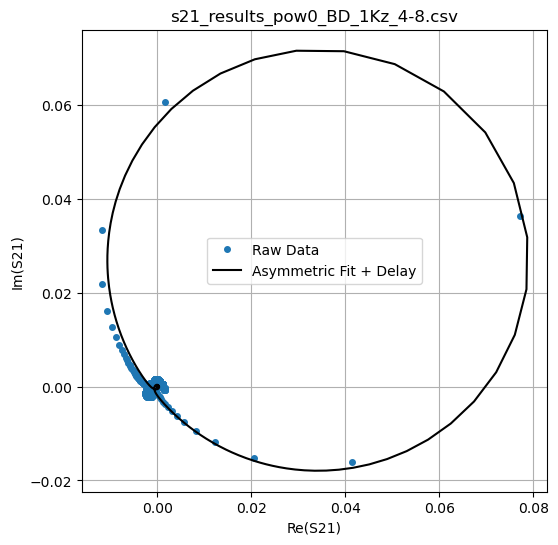

Fit params for s21_results_pow0_BD_1Kz_4-8.csv:
  f0  = 6.133e+09
  k   = 2.868e+06
  amp = 8.829e-02
  phi = 29.160
  tau = 1.718e-09 s


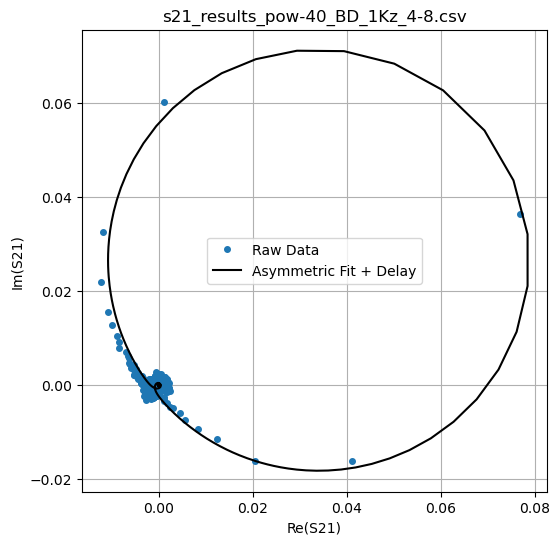

Fit params for s21_results_pow-40_BD_1Kz_4-8.csv:
  f0  = 6.133e+09
  k   = 2.893e+06
  amp = 8.794e-02
  phi = 43.099
  tau = 2.080e-09 s


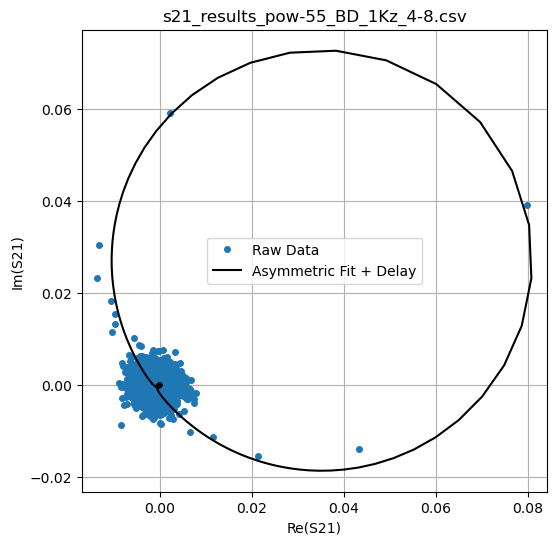

Fit params for s21_results_pow-55_BD_1Kz_4-8.csv:
  f0  = 6.133e+09
  k   = 2.860e+06
  amp = 9.008e-02
  phi = 27.562
  tau = 1.677e-09 s


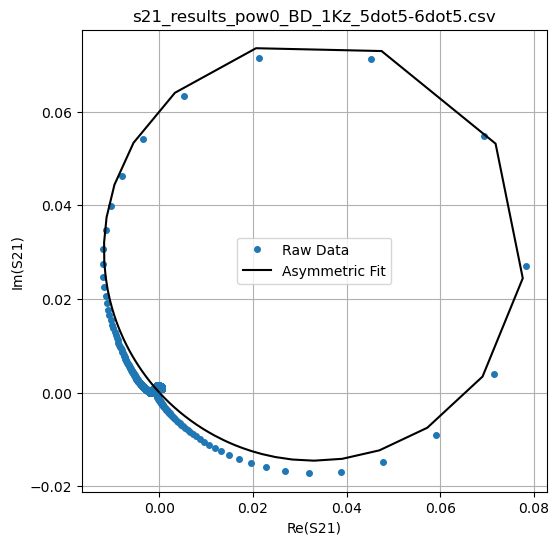

Fit params for s21_results_pow0_BD_1Kz_5dot5-6dot5.csv:
  f0  = 6.133e+09
  k   = 2.760e+06
  amp = 8.988e-02
  phi = 0.743


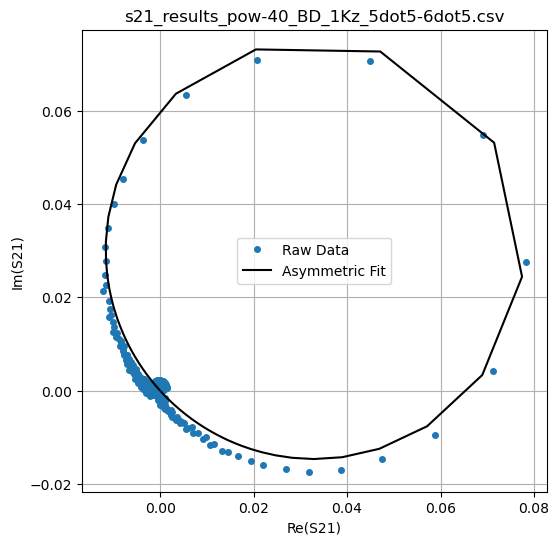

Fit params for s21_results_pow-40_BD_1Kz_5dot5-6dot5.csv:
  f0  = 6.133e+09
  k   = 2.759e+06
  amp = 8.949e-02
  phi = 0.739


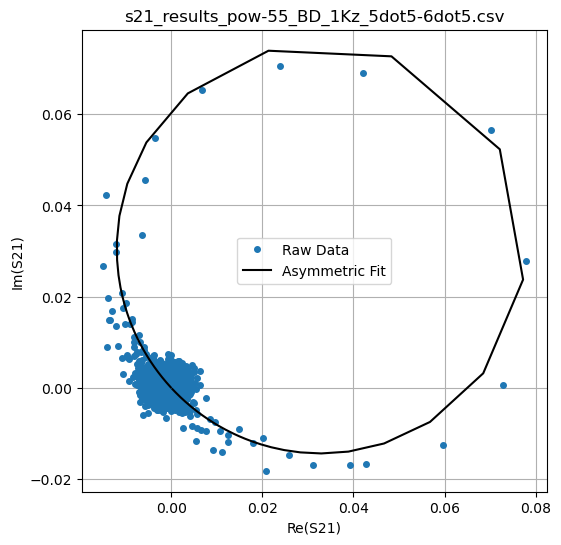

Fit params for s21_results_pow-55_BD_1Kz_5dot5-6dot5.csv:
  f0  = 6.133e+09
  k   = 2.767e+06
  amp = 8.976e-02
  phi = 0.748
